<a href="https://colab.research.google.com/github/bayan2002/Chicago-Crime-Time-Series-Analysis/blob/main/Chicago_Crime_Analysis_Part2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 5.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.tsa.api as tsa
import holidays
from statsmodels.tsa.seasonal import seasonal_decompose
from pmdarima.model_selection import train_test_split
from pmdarima.arima.utils import ndiffs, nsdiffs

plt.rcParams['figure.figsize'] = (12, 4)
sns.set_context("talk", font_scale=0.9)

In [ ]:
def plot_forecast(ts_train, ts_test, forecast_df, n_train_lags=None,
                  figsize=(10,4), title='Comparing Forecast vs. True Data'):
    ### PLot training data, and forecast (with upper/,lower ci)
    fig, ax = plt.subplots(figsize=figsize)

    # setting the number of train lags to plot if not specified
    if n_train_lags==None:
        n_train_lags = len(ts_train)

    # Plotting Training  and test data
    ts_train.iloc[-n_train_lags:].plot(ax=ax, label="train")
    ts_test.plot(label="test", ax=ax)

    # Plot forecast
    forecast_df['mean'].plot(ax=ax, color='green', label="forecast")

    # Add the shaded confidence interval
    ax.fill_between(forecast_df.index,
                    forecast_df['mean_ci_lower'],
                   forecast_df['mean_ci_upper'],
                   color='green', alpha=0.3,  lw=2)

    # set the title and add legend
    ax.set_title(title)
    ax.legend();

    return fig, ax

In [ ]:
# Custom function for Ad Fuller Test
def get_adfuller_results(ts, alpha=.05, label='adfuller', **kwargs): #kwargs for adfuller()
    # Saving each output
    (test_stat, pval, nlags, nobs, crit_vals_d,
    icbest ) = tsa.adfuller(ts, **kwargs)
    # Converting output to a dictionary with the interpretation of p
    adfuller_results = {'Test Statistic': test_stat,
                        "# of Lags Used":nlags,
                       '# of Observations':nobs,
                        'p-value': round(pval,6),
                        'alpha': alpha,
                       'sig/stationary?': pval < alpha}
    return pd.DataFrame(adfuller_results, index =[label])

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

def regression_metrics_ts(ts_true, ts_pred, label="", verbose=True, output_dict=False,):
    # Get metrics
    mae = mean_absolute_error(ts_true, ts_pred)
    mse = mean_squared_error(ts_true, ts_pred)
    rmse = np.sqrt(mse)
    r_squared = r2_score(ts_true, ts_pred)
    mae_perc = mean_absolute_percentage_error(ts_true, ts_pred) * 100

    if verbose == True:
        # Print Result with label
        header = "---" * 20
        print(header, f"Regression Metrics: {label}", header, sep="\n")
        print(f"- MAE = {mae:,.3f}")
        print(f"- MSE = {mse:,.3f}")
        print(f"- RMSE = {rmse:,.3f}")
        print(f"- R^2 = {r_squared:,.3f}")
        print(f"- MAPE = {mae_perc:,.2f}%")

    if output_dict == True:
        metrics = {
            "Label": label,
            "MAE": mae,
            "MSE": mse,
            "RMSE": rmse,
            "R^2": r_squared,
            "MAPE(%)": mae_perc,
        }
        return metrics

In [ ]:
def get_sig_lags(ts, type='ACF',  nlags=None,alpha=0.5):


    if type == 'ACF':
        # Running the function used by plot_acf
        corr_values, conf_int = tsa.stattools.acf(ts, alpha=alpha, nlags=nlags)

    elif type=='PACF':
        corr_values, conf_int = tsa.stattools.pacf(ts, alpha=alpha, nlags=nlags)

    else:
        raise Exception("type must be either 'ACF' or 'PACF'")

    # Determine lags
    lags =range(len(corr_values))

    # Create a centered version of the acf_df
    corr_df = pd.DataFrame({type:corr_values,
                            'Lags':lags,
                            'lower ci': conf_int[:,0]-corr_values, # subtract acf from lower ci to center
                            'upper ci': conf_int[:,1]-corr_values, # subtact acf to upper ci to center
                                 })
    corr_df = corr_df.set_index("Lags")

    # Getting filter for sig lags
    filter_sig_lags = (corr_df[type] < corr_df['lower ci']) | (corr_df[type] > corr_df['upper ci'])

    # Get lag #'s
    sig_lags= corr_df.index[filter_sig_lags]
    sig_lags = sig_lags[sig_lags!=0]

    return sig_lags

In [ ]:
def plot_acf_pacf(ts, nlags=40, figsize=(10, 5),
                  annotate_sig=False, alpha=.05,
                 acf_kws={}, pacf_kws={},
                  annotate_seas=False, m = None,
                 seas_color='black'):

    fig, axes = plt.subplots(nrows=2, figsize=figsize)


    # Sig lags line style
    sig_vline_kwargs = dict( ls=':', lw=1, zorder=0, color='red')

    # ACF
    tsa.graphics.plot_acf(ts, ax=axes[0], lags=nlags, **acf_kws)

    ## Annotating sig acf lags
    if annotate_sig == True:
        sig_acf_lags = get_sig_lags(ts,nlags=nlags,alpha=alpha, type='ACF')
        for lag in sig_acf_lags:
            axes[0].axvline(lag,label='sig', **sig_vline_kwargs )

    # PACF
    tsa.graphics.plot_pacf(ts,ax=axes[1], lags=nlags, **pacf_kws)

    ## Annotating sig pacf lags
    if annotate_sig == True:
        ## ANNOTATING SIG LAGS
        sig_pacf_lags = get_sig_lags(ts,nlags=nlags,alpha=alpha, type='PACF')
        for lag in sig_pacf_lags:
            axes[1].axvline(lag, label='sig', **sig_vline_kwargs)




    ### ANNOTATE SEASONS
    if annotate_seas == True:
        # Ensure m was defined
        if m is None:
            raise Exception("Must define value of m if annotate_seas=True.")

        ## Calculate number of complete seasons to annotate
        n_seasons = nlags//m

        # Seasonal Lines style
        seas_vline_kwargs = dict( ls='--',lw=1, alpha=.7, color=seas_color, zorder=-1)

        ## for each season, add a line
        for i in range(1, n_seasons+1):
            axes[0].axvline(m*i, **seas_vline_kwargs, label="season")
            axes[1].axvline(m*i, **seas_vline_kwargs, label="season")

    fig.tight_layout()

    return fig

#Load the data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
import os
import glob

zip_path = "/content/drive/MyDrive/AXSOSACADEMY/06-AdvancedML/Week21/Data/Chicago_Crime_2001-2022.zip"
extract_to = "chicago_crime_extracted"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)


all_files = glob.glob(os.path.join(extract_to, "Data/*.csv"))

# قراءة كل ملف ووضعه في قائمة، ثم دمجها جميعاً
df_list = [pd.read_csv(f) for f in all_files]
df = pd.concat(df_list, ignore_index=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7713109 entries, 0 to 7713108
Data columns (total 12 columns):
 #   Column                Dtype  
---  ------                -----  
 0   ID                    int64  
 1   Date                  object 
 2   Primary Type          object 
 3   Description           object 
 4   Location Description  object 
 5   Arrest                bool   
 6   Domestic              bool   
 7   Beat                  int64  
 8   District              float64
 9   Ward                  float64
 10  Latitude              float64
 11  Longitude             float64
dtypes: bool(2), float64(4), int64(2), object(4)
memory usage: 603.2+ MB


In [ ]:

df.head()
df.info()
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

df = df.dropna(subset=['Date'])

df = df.set_index('Date')
df = df.sort_index()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7713109 entries, 0 to 7713108
Data columns (total 12 columns):
 #   Column                Dtype  
---  ------                -----  
 0   ID                    int64  
 1   Date                  object 
 2   Primary Type          object 
 3   Description           object 
 4   Location Description  object 
 5   Arrest                bool   
 6   Domestic              bool   
 7   Beat                  int64  
 8   District              float64
 9   Ward                  float64
 10  Latitude              float64
 11  Longitude             float64
dtypes: bool(2), float64(4), int64(2), object(4)
memory usage: 603.2+ MB


/tmp/ipykernel_2052/3980509000.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce')


In [ ]:
df.head()

,ID,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Latitude,Longitude
Date,,,,,,,,,,,
2001-01-01,3824165,THEFT,FINANCIAL ID THEFT:$300 &UNDER,RESIDENCE,False,False,1121,11.0,26.0,41.899291,-87.707551
2001-01-01,3214584,THEFT,FINANCIAL ID THEFT: OVER $300,STREET,False,False,2221,22.0,21.0,41.732563,-87.669923
2001-01-01,1651806,THEFT,FINANCIAL ID THEFT:$300 &UNDER,RESIDENCE,False,False,1932,19.0,NaN,41.938485,-87.656344
2001-01-01,11950657,OFFENSE INVOLVING CHILDREN,SEXUAL ASSAULT OF CHILD BY FAMILY MEMBER,RESIDENCE,True,True,825,8.0,16.0,NaN,NaN
2001-01-01,9754994,SEX OFFENSE,AGG CRIMINAL SEXUAL ABUSE,CHURCH/SYNAGOGUE/PLACE OF WORSHIP,False,False,1022,10.0,24.0,NaN,NaN


#**Part 2**

In [ ]:
# 1. Transform data into monthly crime counts for two crime types
# Crime 1: Theft
theft_ts = df[df['Primary Type'] == 'THEFT'].resample('MS').size()

# Crime 2: Battery
battery_ts = df[df['Primary Type'] == 'BATTERY'].resample('MS').size()

# 2. Check for and address null values
print(f"Theft nulls: {theft_ts.isna().sum()}")
print(f"Battery nulls: {battery_ts.isna().sum()}")

# Fill missing values using interpolation for continuous trends [5]
theft_ts = theft_ts.interpolate()
battery_ts = battery_ts.interpolate()

Theft nulls: 0
Battery nulls: 0


#Step 2: Decompose Time Series to Detect Seasonality

The seasonal component accounts for ~32.08% of the variation.


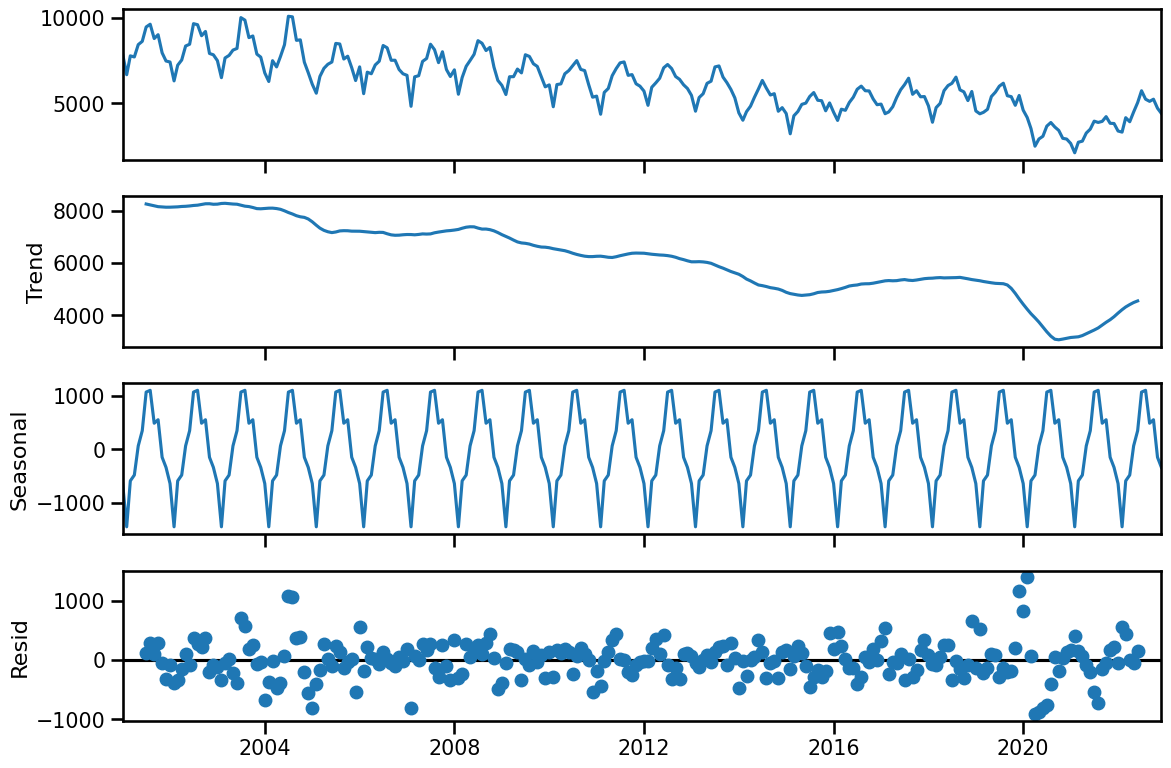

In [ ]:
# 3. Decompose Crime 1 (Theft) to check for seasonality
decomp = tsa.seasonal_decompose(theft_ts)
fig = decomp.plot()
fig.set_size_inches(12, 8)
fig.tight_layout()

# Calculate the magnitude of seasonality relative to total variation [7]
seasonal_delta = decomp.seasonal.max() - decomp.seasonal.min()
variation_pct = (seasonal_delta / (theft_ts.max() - theft_ts.min())) * 100
print(f"The seasonal component accounts for ~{variation_pct:.2f}% of the variation.")

# Determine seasonal period (m=12 for monthly data) [8]
m = 12


#Step 3: Check for Stationarity and Determine Differencing


In [ ]:
# 4. Check for stationarity using AdFuller test
get_adfuller_results(theft_ts, label='Theft Raw Data')

# 5. Determine the number of differencing steps (d and D) [11]
d = ndiffs(theft_ts)
D = nsdiffs(theft_ts, m=m)
print(f"Required differencing: d={d}, D={D}")

# Apply differencing to create stationary data for order estimation
ts_diff = theft_ts.diff(d).dropna()
if D > 0:
    ts_diff = ts_diff.diff(m).dropna()

Required differencing: d=1, D=0


#Step 4: Use ACF and PACF to Estimate Initial Orders


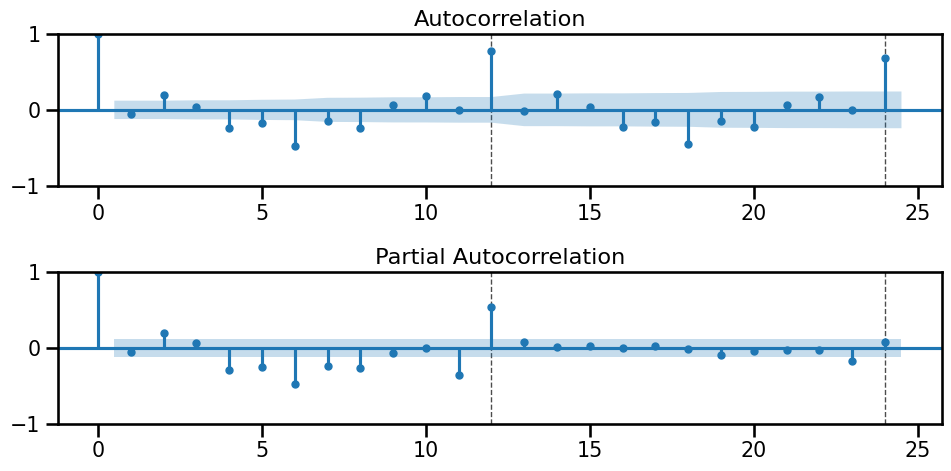

In [ ]:
# 6. Plot ACF and PACF with seasonal annotations [14]
plot_acf_pacf(ts_diff, annotate_seas=True, m=m, nlags=24);

#  Step 5: Train-Test Split

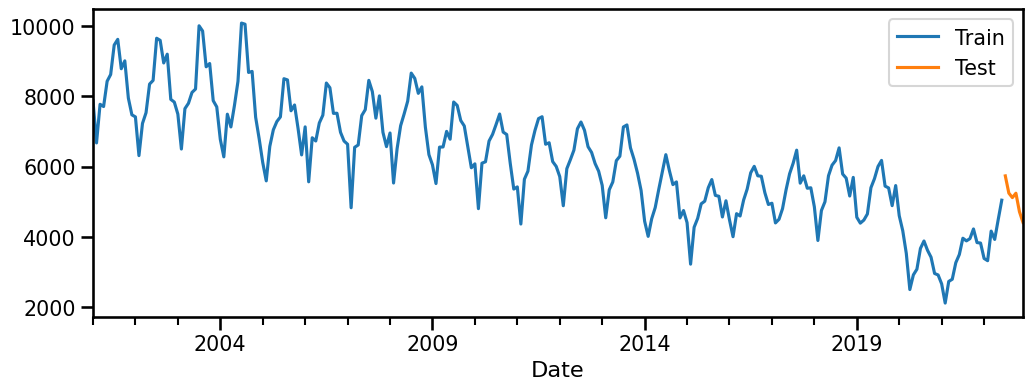

In [ ]:
# 7. Split the time series (6 months for testing)
train, test = train_test_split(theft_ts, test_size=6)

# Visualize the split
ax = train.plot(label='Train')
test.plot(ax=ax, label='Test')
ax.legend();

In [ ]:
# Orders for non seasonal components
p = 0  # nonseasonal AR
d = d  # nonseasonal differencing
q = 1  # nonseasonal MA

# Orders for seasonal components
P = 1  # Seasonal AR
D = D  # Seasonal differencing
Q = 0  # Seasonal MA
m = 12 # Seasonal period

sarima = tsa.ARIMA(train, order = (p,d,q), seasonal_order=(P,D,Q,m)).fit()

# Obtain summary
sarima.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                     
=========================================================================================
Dep. Variable:                                 y   No. Observations:                  258
Model:             ARIMA(0, 1, 1)x(1, 0, [], 12)   Log Likelihood               -1892.036
Date:                           Sun, 05 Jul 2026   AIC                           3790.072
Time:                                   17:23:37   BIC                           3800.719
Sample:                               01-01-2001   HQIC                          3794.354
                                    - 06-01-2022                                         
Covariance Type:                             opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.2047      0.046     -4.420      0.000      -0.296      -0.114
ar.S.L12       0.7915      0.025     31.313      0.000       0.742       0.841
sigma2       1.31e+05   9592.434     13.651      0.000    1.12e+05     1.5e+05
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):                10.53
Prob(Q):                              0.89   Prob(JB):                         0.01
Heteroskedasticity (H):               0.81   Skew:                            -0.16
Prob(H) (two-sided):                  0.33   Kurtosis:                         3.94
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

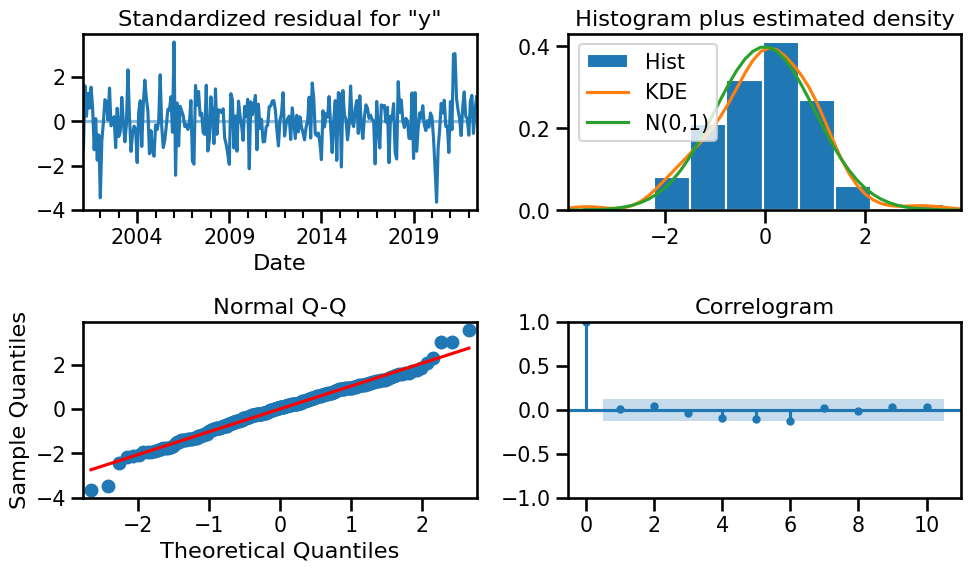

In [ ]:
# Obtain diagnostic plots
fig = sarima.plot_diagnostics()
fig.set_size_inches(10,6)
fig.tight_layout()

------------------------------------------------------------
Regression Metrics: 
------------------------------------------------------------
- MAE = 375.254
- MSE = 201,718.938
- RMSE = 449.131
- R^2 = -0.143
- MAPE = 7.73%


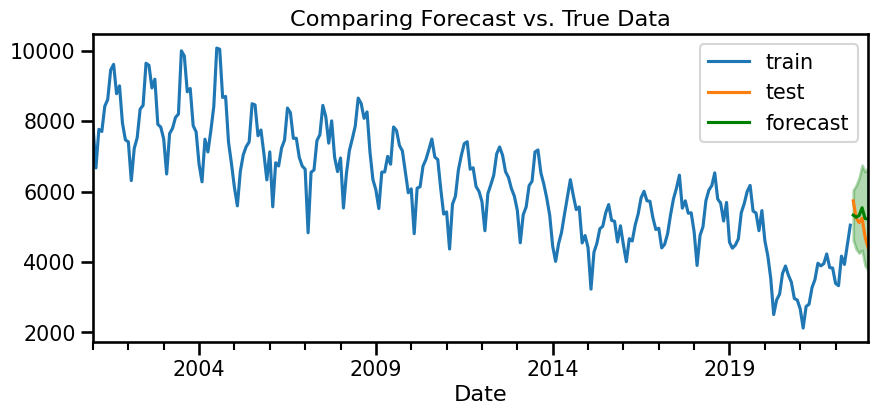

In [ ]:
# Obtain forecast as a dataframe with confidence intervals
forecast_df = sarima.get_forecast(steps=len(test)).summary_frame()
# Call the custom function to plot the forecasts with confidence intervals and true values
plot_forecast(train, test, forecast_df);
# Obtain metrics
regression_metrics_ts(test, forecast_df['mean'])

# **Auto_Arima**

In [ ]:
import pmdarima as pm

# Default auto_arima will select model based on AIC score
auto_model = pm.auto_arima(
    train,
    seasonal=True,
    m=12,
    trace=True
)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=inf, Time=2.45 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=4050.524, Time=0.08 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=3791.710, Time=1.83 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=3914.631, Time=1.60 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=4048.603, Time=0.05 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=4050.805, Time=0.11 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AIC=3774.214, Time=1.88 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : AIC=3743.851, Time=3.13 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=3743.960, Time=1.20 sec
 ARIMA(1,1,0)(2,0,2)[12] intercept   : AIC=inf, Time=2.14 sec
 ARIMA(1,1,0)(1,0,2)[12] intercept   : AIC=3742.901, Time=2.53 sec
 ARIMA(1,1,0)(0,0,2)[12] intercept   : AIC=3870.719, Time=1.41 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=3913.736, Time=1.04 sec
 ARIMA(0,1,0)(1,0,2)[12] intercept   : AIC=3754.859, Time=4.55 sec
 ARIMA(2,1,0)(1,0,2)[12] inte

In [ ]:
# Obtain summary of the best model from auto_arima
auto_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                        SARIMAX Results                                        
===============================================================================================
Dep. Variable:                                       y   No. Observations:                  258
Model:             SARIMAX(1, 1, 0)x(1, 0, [1, 2], 12)   Log Likelihood               -1865.634
Date:                                 Sun, 05 Jul 2026   AIC                           3741.268
Time:                                         17:24:49   BIC                           3759.013
Sample:                                     01-01-2001   HQIC                          3748.404
                                          - 06-01-2022                                         
Covariance Type:                                   opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2251      0.046     -4.934      0.000      -0.315      -0.136
ar.S.L12       0.9778      0.008    120.055      0.000       0.962       0.994
ma.S.L12      -0.5771      0.059     -9.815      0.000      -0.692      -0.462
ma.S.L24      -0.1202      0.068     -1.758      0.079      -0.254       0.014
sigma2      1.038e+05   7353.336     14.120      0.000    8.94e+04    1.18e+05
===================================================================================
Ljung-Box (L1) (Q):                   0.03   Jarque-Bera (JB):                30.54
Prob(Q):                              0.87   Prob(JB):                         0.00
Heteroskedasticity (H):               0.80   Skew:                            -0.44
Prob(H) (two-sided):                  0.31   Kurtosis:                         4.44
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

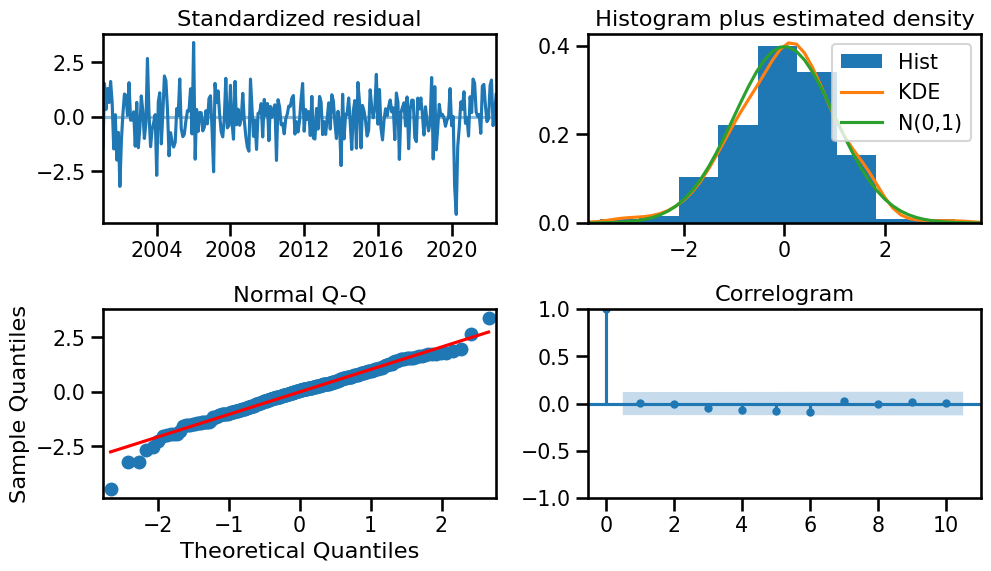

In [ ]:
# Obtain diagnostic plots
fig = auto_model.plot_diagnostics()
fig.set_size_inches(10,6)
fig.tight_layout()

------------------------------------------------------------
Regression Metrics: 
------------------------------------------------------------
- MAE = 211.158
- MSE = 72,805.087
- RMSE = 269.824
- R^2 = 0.587
- MAPE = 4.27%


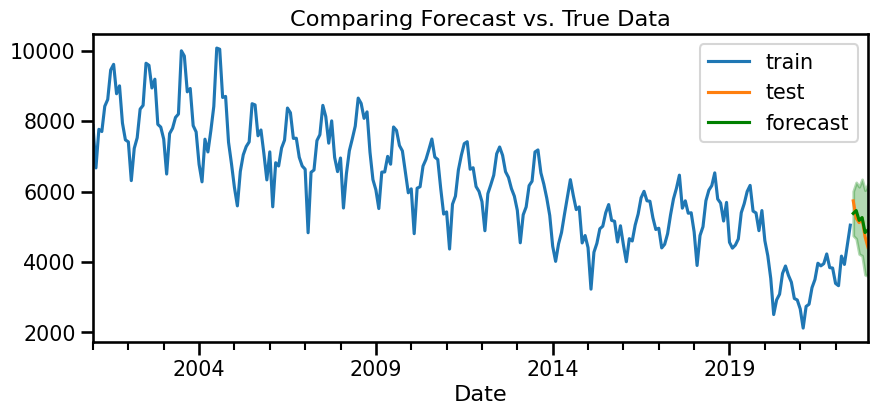

In [ ]:
# Use auto_arima parameters to fit an ARIMA
auto_model = tsa.ARIMA(
    train, order=auto_model.order, seasonal_order=auto_model.seasonal_order
).fit()


# Obtain forecast as a dataframe with confidence intervals
forecast_df = auto_model.get_forecast(steps=len(test)).summary_frame()
# Call the custom function to plot the forecasts with confidence intervals and true values
plot_forecast(train, test, forecast_df);
# Obtain metrics
regression_metrics_ts(test, forecast_df['mean'])

# **Final Model Selection and Justification (Theft)**

Manual SARIMA (0,1,1)(1,0,0,12)

Tuned SARIMA (1,1,0)(1,0,2,12)

# **Justification:**
## The Tuned SARIMA model was selected as the final model for forecasting Theft crimes. It outperformed the manual model across all key evaluation metrics
## Specifically, it achieved a significantly lower AIC (3741.27 vs 3790.07), indicating a better balance between model fit and complexity
## Furthermore, the predictive accuracy on the test set improved substantially, with the MAPE dropping from 7.73% to 4.27% and the R2 increasing from a negative value to 0.587
## Diagnostic tests for both models showed high Prob(Q) values (> 0.05), confirming that the residuals behave like White Noise and that the models effectively captured the underlying patterns

# **True Future Forecast for Theft**


(<Figure size 1000x400 with 1 Axes>,
 <Axes: title={'center': 'True Future Forecast for Theft in Chicago'}, xlabel='Date'>)

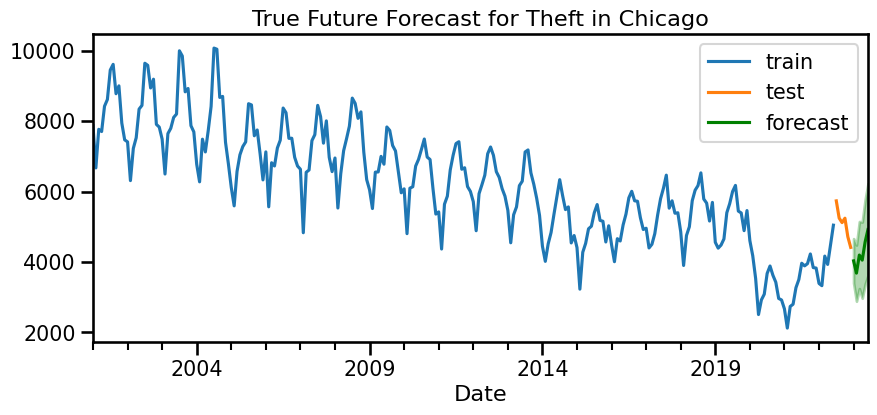

In [ ]:
# 1. Retrain the best model on the entire theft_ts dataset
final_theft_model = tsa.ARIMA(theft_ts,
                              order=(1, 1, 0),
                              seasonal_order=(1, 0, 2, 12)).fit()

# 2. Forecast 6 months into the true future
theft_future_forecast = final_theft_model.get_forecast(steps=6).summary_frame()

# 3. Plot the true future forecast
plot_forecast(train, test, theft_future_forecast, title="True Future Forecast for Theft in Chicago")

# **Theft Forecast Calculations**
**Predicted Net Change:** The typical monthly count for Theft crimes is forecasted to increase by 893.65 crimes over the next 6 months

**Percent Change:** This represents a significant 22.19% increase from the start of the forecast period to the end




#Step 2: Decompose Time Series to Detect Seasonality

In [ ]:
# 3. Decompose Crime 1 (Theft) to check for seasonality
decomp = tsa.seasonal_decompose(theft_ts)
fig = decomp.plot()
fig.set_size_inches(12, 8)
fig.tight_layout()

# Calculate the magnitude of seasonality relative to total variation [7]
seasonal_delta = decomp.seasonal.max() - decomp.seasonal.min()
variation_pct = (seasonal_delta / (theft_ts.max() - theft_ts.min())) * 100
print(f"The seasonal component accounts for ~{variation_pct:.2f}% of the variation.")

# Determine seasonal period (m=12 for monthly data) [8]
m = 12


# **Battery Crimes**

#Step 3: Check for Stationarity and Determine Differencing


In [ ]:
# 4. Check for stationarity using AdFuller test
get_adfuller_results(battery_ts, label='Battery Raw Data')

# 5. Determine the number of differencing steps (d and D)
d = ndiffs(battery_ts)
D = nsdiffs(battery_ts, m=m)
print(f"Required differencing: d={d}, D={D}")

# Apply differencing to create stationary data for order estimation
ts_diff = battery_ts.diff(d).dropna()
if D > 0:
    ts_diff = ts_diff.diff(m).dropna()

Required differencing: d=1, D=0


#Step 4: Use ACF and PACF to Estimate Initial Orders


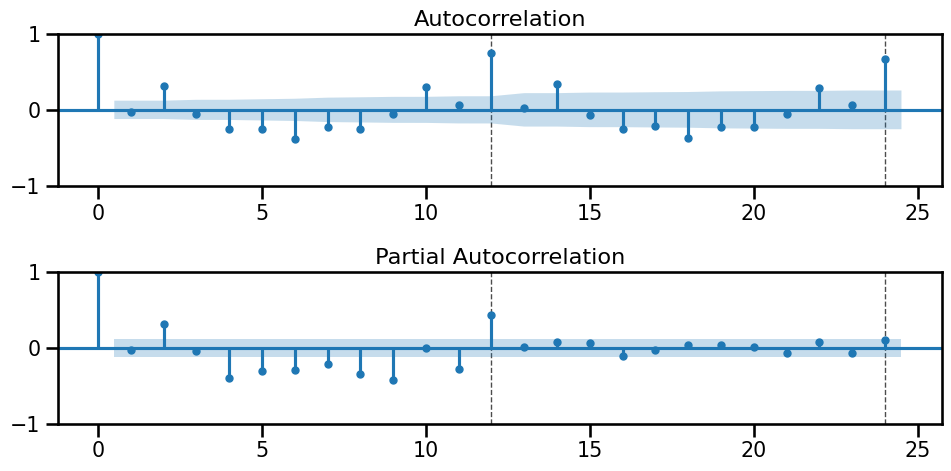

In [ ]:
# 6. Plot ACF and PACF with seasonal annotations [14]
plot_acf_pacf(ts_diff, annotate_seas=True, m=m, nlags=24);

#  Step 5: Train-Test Split

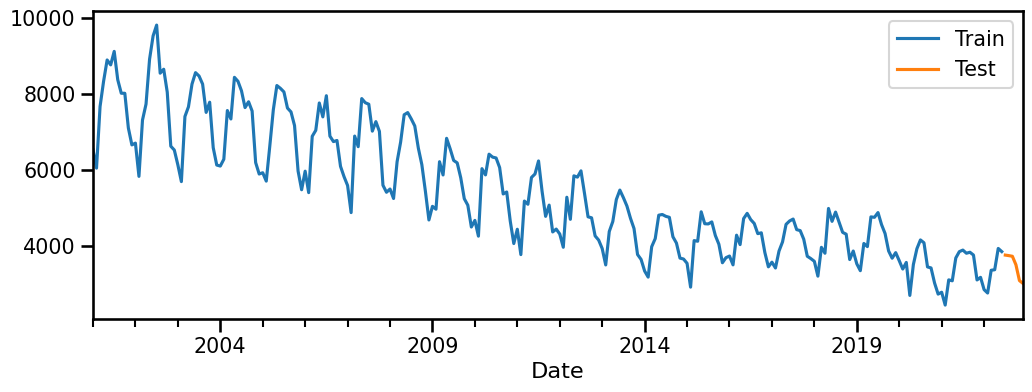

In [ ]:
# 7. Split the time series (6 months for testing)
train, test = train_test_split(battery_ts, test_size=6)

# Visualize the split
ax = train.plot(label='Train')
test.plot(ax=ax, label='Test')
ax.legend();

In [ ]:
# Orders for non seasonal components
p = 1  # nonseasonal AR
d = d  # nonseasonal differencing
q = 0  # nonseasonal MA

# Orders for seasonal components
P = 1  # Seasonal AR
D = D  # Seasonal differencing
Q = 0  # Seasonal MA
m = 12 # Seasonal period

sarima = tsa.ARIMA(train, order = (p,d,q), seasonal_order=(P,D,Q,m)).fit()

# Obtain summary
sarima.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                    SARIMAX Results                                     
========================================================================================
Dep. Variable:                                y   No. Observations:                  258
Model:             ARIMA(1, 1, 0)x(1, 0, 0, 12)   Log Likelihood               -1872.706
Date:                          Sun, 05 Jul 2026   AIC                           3751.413
Time:                                  17:39:33   BIC                           3762.060
Sample:                              01-01-2001   HQIC                          3755.695
                                   - 06-01-2022                                         
Covariance Type:                            opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3180      0.052     -6.090      0.000      -0.420      -0.216
ar.S.L12       0.7997      0.027     29.114      0.000       0.746       0.854
sigma2      1.141e+05   9759.119     11.692      0.000     9.5e+04    1.33e+05
===================================================================================
Ljung-Box (L1) (Q):                   0.17   Jarque-Bera (JB):                 2.73
Prob(Q):                              0.68   Prob(JB):                         0.26
Heteroskedasticity (H):               0.36   Skew:                             0.19
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.33
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

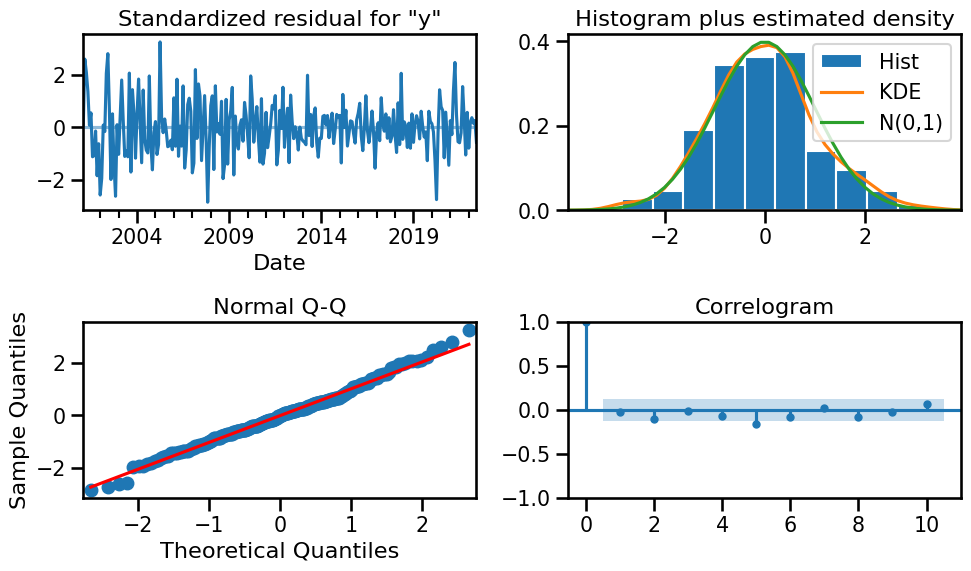

In [ ]:
# Obtain diagnostic plots
fig = sarima.plot_diagnostics()
fig.set_size_inches(10,6)
fig.tight_layout()

------------------------------------------------------------
Regression Metrics: 
------------------------------------------------------------
- MAE = 228.160
- MSE = 58,895.307
- RMSE = 242.684
- R^2 = 0.392
- MAPE = 6.78%


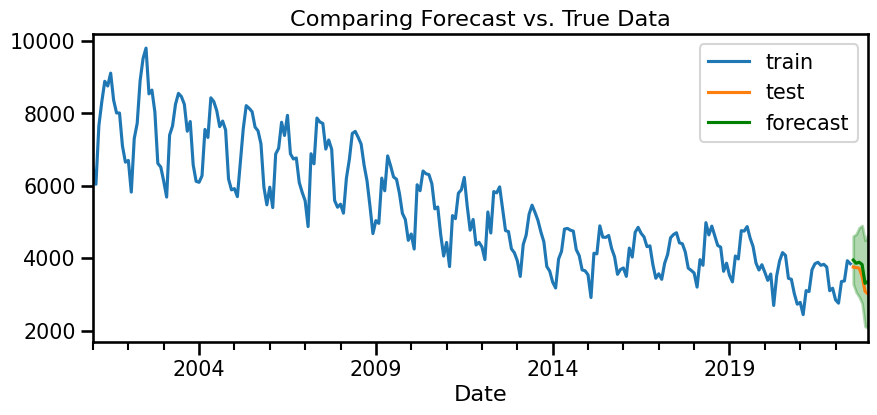

In [ ]:
# Obtain forecast as a dataframe with confidence intervals
forecast_df = sarima.get_forecast(steps=len(test)).summary_frame()
# Call the custom function to plot the forecasts with confidence intervals and true values
plot_forecast(train, test, forecast_df);
# Obtain metrics
regression_metrics_ts(test, forecast_df['mean'])

# **Auto_Arima**

In [ ]:
import pmdarima as pm

# Default auto_arima will select model based on AIC score
auto_model = pm.auto_arima(
    train,
    seasonal=True,
    m=12,
    trace=True
)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=inf, Time=1.97 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=3999.181, Time=0.03 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=3753.329, Time=0.55 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=3872.017, Time=0.46 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=3997.267, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=4000.706, Time=0.05 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AIC=inf, Time=1.77 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=3680.737, Time=1.33 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=3870.170, Time=1.06 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : AIC=3688.922, Time=5.46 sec
 ARIMA(1,1,0)(1,0,2)[12] intercept   : AIC=3682.671, Time=2.59 sec
 ARIMA(1,1,0)(0,0,2)[12] intercept   : AIC=3836.662, Time=1.08 sec
 ARIMA(1,1,0)(2,0,2)[12] intercept   : AIC=inf, Time=3.53 sec
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=3704.855, Time=0.94 sec
 ARIMA(2,1,0)(1,0,1)[12] intercept

/usr/local/lib/python3.12/dist-packages/pmdarima/arima/_auto_solvers.py:524: ModelFitWarning: Error fitting  ARIMA(2,1,1)(1,0,1)[12]           (if you do not want to see these warnings, run with error_action="ignore").
Traceback:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pmdarima/arima/_auto_solvers.py", line 508, in _fit_candidate_model
    fit.fit(y, X=X, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/pmdarima/arima/arima.py", line 610, in fit
    self._fit(y, X, **fit_args)
  File "/usr/local/lib/python3.12/dist-packages/pmdarima/arima/arima.py", line 531, in _fit
    fit, self.arima_res_ = _fit_wrapper()
                           ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pmdarima/arima/arima.py", line 517, in _fit_wrapper
    fitted = arima.fit(
             ^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py", line 705, in fit
    mlefit = super().fit(start_p

 ARIMA(2,1,1)(1,0,1)[12]             : AIC=inf, Time=nan sec
 ARIMA(1,1,1)(1,0,1)[12]             : AIC=inf, Time=1.14 sec
 ARIMA(3,1,1)(1,0,1)[12]             : AIC=inf, Time=2.12 sec

Best model:  ARIMA(2,1,0)(1,0,1)[12]          
Total fit time: 77.758 seconds


In [ ]:
# Obtain summary of the best model from auto_arima
auto_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                                    y   No. Observations:                  258
Model:             SARIMAX(2, 1, 0)x(1, 0, [1], 12)   Log Likelihood               -1833.518
Date:                              Sun, 05 Jul 2026   AIC                           3677.037
Time:                                      17:42:00   BIC                           3694.782
Sample:                                  01-01-2001   HQIC                          3684.173
                                       - 06-01-2022                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3590      0.056     -6.388      0.000      -0.469      -0.249
ar.L2         -0.1261      0.055     -2.290      0.022      -0.234      -0.018
ar.S.L12       0.9840      0.006    169.145      0.000       0.973       0.995
ma.S.L12      -0.6853      0.057    -12.115      0.000      -0.796      -0.574
sigma2      8.026e+04   6989.335     11.484      0.000    6.66e+04     9.4e+04
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                 1.84
Prob(Q):                              0.94   Prob(JB):                         0.40
Heteroskedasticity (H):               0.42   Skew:                             0.01
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.41
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

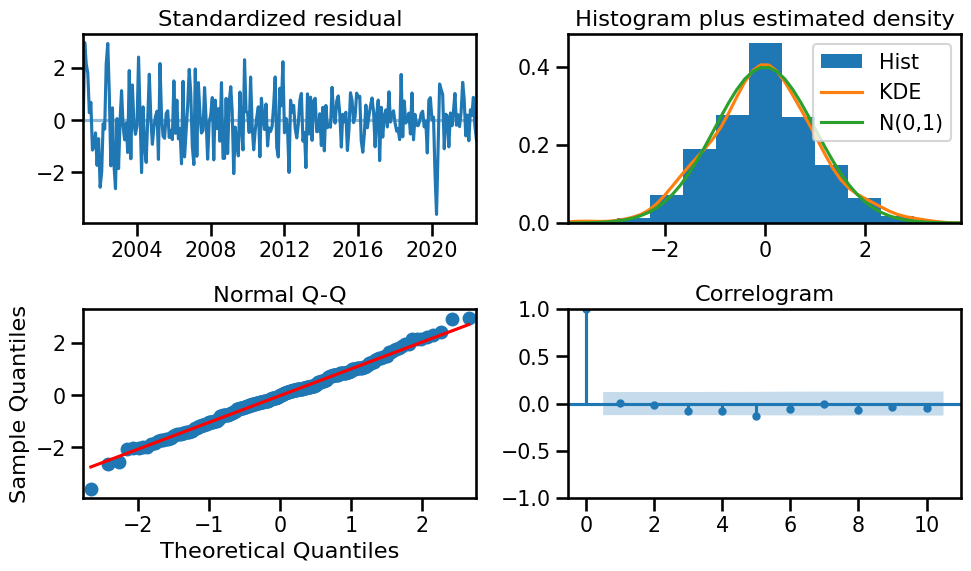

In [ ]:
# Obtain diagnostic plots
fig = auto_model.plot_diagnostics()
fig.set_size_inches(10,6)
fig.tight_layout()

------------------------------------------------------------
Regression Metrics: 
------------------------------------------------------------
- MAE = 95.192
- MSE = 17,440.190
- RMSE = 132.061
- R^2 = 0.820
- MAPE = 2.61%


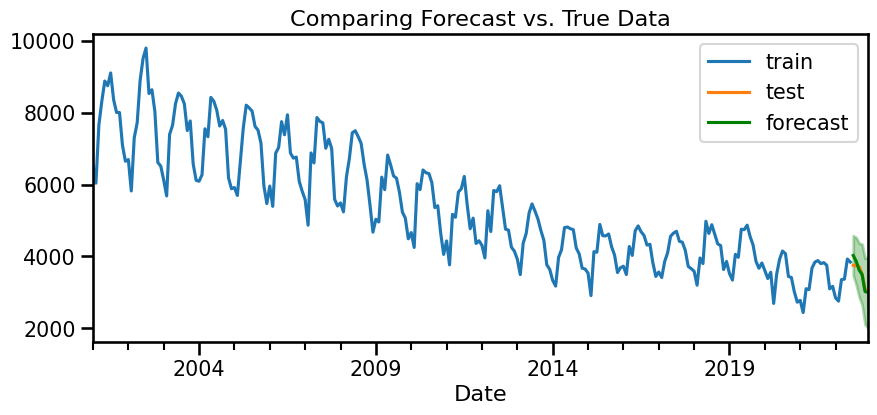

In [ ]:
# Use auto_arima parameters to fit an ARIMA
auto_model = tsa.ARIMA(
    train, order=auto_model.order, seasonal_order=auto_model.seasonal_order
).fit()


# Obtain forecast as a dataframe with confidence intervals
forecast_df = auto_model.get_forecast(steps=len(test)).summary_frame()
# Call the custom function to plot the forecasts with confidence intervals and true values
plot_forecast(train, test, forecast_df);
# Obtain metrics
regression_metrics_ts(test, forecast_df['mean'])

# **Final Model Selection and Justification (Theft)**

Manual SARIMA (1,1,0)(1,0,0,12)

Tuned SARIMA (2,1,0)(1,0,1)[12]  

# **Justification:**
## The Tuned SARIMA model was selected as the final model for forecasting Theft crimes. It outperformed the manual model across all key evaluation metrics
## Specifically, it achieved a significantly lower AIC (	3677.037 vs	3751.413), indicating a better balance between model fit and complexity
## Furthermore, the predictive accuracy on the test set improved substantially, with the MAPE dropping from 6.78% to 2.61% and the R2 increasing from 0.392 to 0.820
## Diagnostic tests for both models showed high Prob(Q) values (> 0.05), confirming that the residuals behave like White Noise and that the models effectively captured the underlying patterns

# **True Future Forecast for Battery crimes**


(<Figure size 1000x400 with 1 Axes>,
 <Axes: title={'center': 'True Future Forecast for Battery in Chicago'}, xlabel='Date'>)

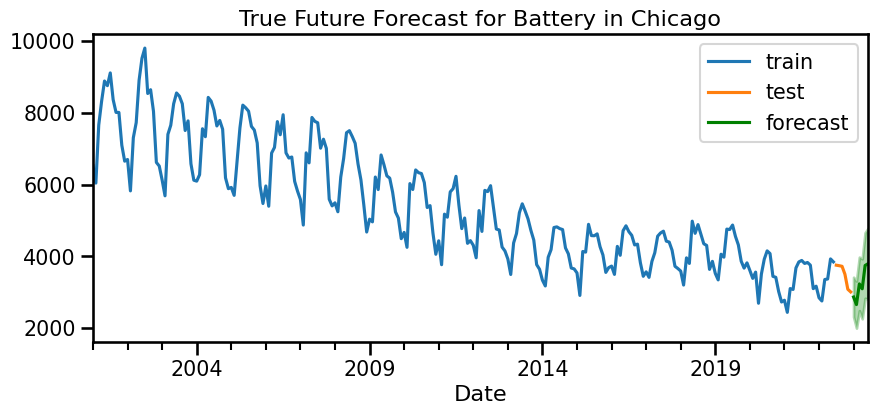

In [ ]:
# 1. Retrain the best model on the entire battery_ts dataset
final_battery_model = tsa.ARIMA(battery_ts,
                                order=(2, 1, 0),
                                seasonal_order=(1, 0, 1, 12)).fit()

# 2. Forecast 6 months into the true future (beyond the dataset)
battery_future_forecast = final_battery_model.get_forecast(steps=6).summary_frame()

# 3. Plot the true future forecast for Battery
plot_forecast(train, test, battery_future_forecast, title="True Future Forecast for Battery in Chicago")

In [39]:
# Extract starting and ending values from the future forecast
starting_val = forecast_df['mean'].iloc[0]
final_val = battery_future_forecast['mean'].iloc[-1]

# Calculate Net Change and Percent Change
net_change = final_val - starting_val
percent_change = (net_change / starting_val) * 100

print(f"Starting Forecast Value: {starting_val:.2f}")
print(f"Ending Forecast Value: {final_val:.2f}")
print(f"Predicted Net Change: {net_change:.2f}")
print(f"Percent Change: {percent_change:.2f}%")
print(f"Percent Change: {percent_change:.2f}%")

Starting Forecast Value: 4027.14
Ending Forecast Value: 3793.49
Predicted Net Change: -233.65
Percent Change: -5.80%
Percent Change: -5.80%


# **Battery Forecast Calculations**
**Predicted Net Change:** The typical monthly count for Battery crimes is forecasted to decrease by 233.65 crimes over the next 6 months.


**Percent Change:**
-5.80%
##This is a percent decrease of about 6%.


# **Final Evaluation & Comparison**
## Using the 6-month "True Future Forecasts" for both crimes, we can compare the expected trends to help Chicago law enforcement allocate resources:
# **Which crime has the highest monthly count at the end of the forecast?**
## Theft is expected to have the highest monthly count, reaching approximately 4,921 incidents, compared to Battery which is expected to end at roughly 3,793
# **Which crime has the highest net change?**
## Theft shows the highest net change with an expected increase of 893.65 crimes, whereas Battery is expected to decrease numerically
# **Which crime has the highest percent change?**
## Theft is forecasted to have the most dramatic relative growth with a 22.19% increase. In contrast, Battery is expected to decline by approximately 5.80%
# **Final Recommendations**
## **Resource Prioritization:** I strongly recommend that the Chicago Police Department prioritize and increase resource allocation toward Theft prevention. The model predicts a sharp 22.19% rise in theft incidents over the coming months, representing nearly 900 additional crimes per month by the end of the period.
## **Strategic Reallocation:** Given that Battery crimes are forecasted to decrease by 5.80%, stakeholders should consider reallocating some officers or mobile units from Battery-heavy sectors to high-risk commercial and residential areas where Theft is expected to surge
## **Visual Support & Reliability:** This recommendation is supported by our Tuned SARIMA model (1,1,0)x(1,0,2,12), which achieved a reliable R2 of 0.587 and a low MAPE of 4.27%.
## The diagnostic tests (Prob(Q) = 0.87) confirm that the model's residuals are White Noise, indicating the forecast effectively captures the underlying crime patterns.
## **Action Plan:** Patrols and surveillance should be intensified starting in the first month of the forecast to mitigate the predicted upward trend shown in the "True Future Forecast" visual
.